# Imports

In [1]:
# Enable autoreload to automatically update changes made in .py files
%load_ext autoreload
%autoreload 2

# # # ACTIVATE INTERACTIVE MATPLOTLIB
# %matplotlib widget


import time
import math
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from IPython.display import display, clear_output


# Helpers and Setup
from helpers import create_viewable_json
from analysis import set_attenuation,set_input_attenuation
from single_qubit_experiment_helpers.experiment import Experiment
from qblox_scheduler import HardwareAgent
from custom_elements import FluxTunableTransmonElement

# =====================================================================
# EXPERIMENT CLASSES (Ordered by Tune-up Sequence)
# =====================================================================

# 0. Hardware Setup
from cal00_time_of_flight import TimeOfFlight

# 1. Resonator (Readout) Tune-up
from cal01_resonator_spectroscopy_full_bandwidth import MultiplexedResonatorSpectroscopyFullBandwidth
from cal02_resonator_spectroscopy import MultiplexedResonatorSpectroscopy
from cal03_resonator_punchout import MultiplexedResonatorPunchout, MultiplexedResonatorPunchoutAmp
from cal04_resonator_flux_spectroscopy import MultiplexedResonatorFluxSpectroscopy
from cal04b_compensated_flux_spectroscopy import CompensatedResonatorFluxSpectroscopy
from cal23_unit_cell_crosstalk import UnitCellCrosstalkCalibration

# 2. Qubit Tune-up (Coarse)
from cal05_qubit_spectroscopy import MultiplexedQubitSpectroscopy
from cal05b_qubit_and_res_spectroscopy import MultiplexedResonatorQubitSpectroscopy
from cal05b_test import MultiplexedResonatorQubitSpectroscopyTEST
from cal06_power_rabi import MultiplexedPowerRabi
from cal07_pulsed_flux_qubit_spectroscopy import MultiplexedPulsedFluxQubitSpectroscopy
from cal07b_CW_flux_qubit_spectroscopy import MultiplexedCWFluxQubitSpectroscopy

# 3. Qubit Tune-up (Fine)
from cal08_pi_pulse_error_amplification import MultiplexedPiPulseErrorAmplification
from cal09_pi_half_pulse_error_amplification import MultiplexedPiHalfPulseErrorAmplification
from cal10_ramsey import MultiplexedRamsey
from cal11_ramsey_vs_flux import MultiplexedRamseyVsFlux
from cal12_drag_pulse_calibration import MultiplexedDRAGCalibration

# 4. Coherence & Readout Optimization
from cal13_dispersive_shift import MultiplexedDispersiveShift
from cal14_t1 import MultiplexedT1  # or import from fast_t1_multiplexed
from cal15_echo import MultiplexedEcho
from cal16_ssro import MultiplexedSSRO, MultiplexedReadoutAmplitudeOptimization, MultiplexedReadoutFrequencyOptimization
from cal17_readout_amplitude_calibration import MultiplexedReadoutAmplitudeCalibration

# 5. Verification & Advanced Hardware
from cal18_allxy import MultiplexedAllXY
from cal19_active_reset import MultiplexedActiveReset
# from cal20_cryoscope import MultiplexedCryoscope (Once implemented)
# from cal21_defect_spectroscopy import MultiplexedDefectSpectroscopy
# from cal22_coupled_qubits_chevron import MultiplexedCoupledQubitsChevron

from demo_01_dual_drive_ramsey import DualDriveRamsey
# from demo_02_dual_drive_echo import DualDriveSpinEcho


# =============================================================================
# GLOBAL PLOT SETTINGS
# =============================================================================
# Change the font family (e.g., 'sans-serif', 'serif', 'monospace')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans'] 

# Change font sizes globally
plt.rcParams['font.size'] = 12           # Default text size
plt.rcParams['axes.labelsize'] = 14      # X and Y label size
plt.rcParams['axes.titlesize'] = 14      # Title size
plt.rcParams['xtick.labelsize'] = 11     # X tick label size
plt.rcParams['ytick.labelsize'] = 11     # Y tick label size

# Change axis and tick thickness
plt.rcParams['axes.linewidth'] = 2.0      # Thickness of the plot box
plt.rcParams['xtick.major.width'] = 2.0   # Thickness of X ticks
plt.rcParams['ytick.major.width'] = 2.0   # Thickness of Y ticks
plt.rcParams['xtick.minor.width'] = 1.5   # Thickness of minor X ticks
plt.rcParams['ytick.minor.width'] = 1.5   # Thickness of minor Y ticks

# (Optional) Make the ticks point inwards instead of outwards
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

/Users/renychang/Downloads/flux-tunable-transmons-with-flux-tunable-couplers-share_with_AS_for_training/.venv/lib/python3.11/site-packages/quantify_core/utilities/general.py:13: QCoDeSDeprecationWarning: The `qcodes.utils.helpers` module is deprecated. Please consult the api documentation at https://microsoft.github.io/Qcodes/api/index.html for alternatives.
  from qcodes.utils.helpers import NumpyJSONEncoder


## Connect to cluster and create hardware agent

In [18]:
from qblox_scheduler.qblox.hardware_agent import HardwareAgent
from single_qubit_experiment_helpers.experiment import Experiment

# 1. Initialize the Hardware Agent
hw_agent = HardwareAgent(
    hardware_configuration="./dependencies/configs/hw_config_AS_QRC.json",
    quantum_device_configuration="./dependencies/configs/dut_config_AS_QRC.json",
    output_dir=r"/Users/renychang/Desktop/qblox"
)

Experiment.hw_agent = hw_agent
Experiment.quantum_device = hw_agent.quantum_device

# 2. Fetch Qubits
q3 = hw_agent.quantum_device.get_element("q3")
q4 = hw_agent.quantum_device.get_element("q4")
q5 = hw_agent.quantum_device.get_element("q5")
q6 = hw_agent.quantum_device.get_element("q6")
q7A = hw_agent.quantum_device.get_element("q7A")
q7B = hw_agent.quantum_device.get_element("q7B")
q8 = hw_agent.quantum_device.get_element("q8")

# 3. Fetch Couplers
c34 = hw_agent.quantum_device.get_element("c34")
c45 = hw_agent.quantum_device.get_element("c45")
c56 = hw_agent.quantum_device.get_element("c56")
c67 = hw_agent.quantum_device.get_element("c67")
c78 = hw_agent.quantum_device.get_element("c78")

# 4. Divide Qubits by Multiplexed Readout Port
# Cluster B - Module 18
qubits_ro_3_5 = [q3, q4, q5]

# Cluster A - Module 20
qubits_ro_6_8 = [q6, q7A, q8]

# Master lists for easy iteration
all_qubits = qubits_ro_3_5 + qubits_ro_6_8
all_couplers = [c34, c45, c56, c67, c78]
all_elements = all_qubits + all_couplers

# 5. Fetch Global Hardware Objects
clusters = hw_agent.get_clusters() # Note: returns a dict with 'cluster_A' and 'cluster_B'
hw_options = hw_agent.hardware_configuration.hardware_options

# 6. Verification Printout
print("\n--- Hardware Agent Initialized ---")
print(f"Total Qubits Loaded: {len(all_qubits)}")
print(f"Total Couplers Loaded: {len(all_couplers)}")
print(f"Readout Group 1 (3-5): {[q.name for q in qubits_ro_3_5]}")
print(f"Readout Group 2 (6-8): {[q.name for q in qubits_ro_6_8]}")

TimeoutError: timed out

In [7]:
# Use .items() if you want both the name and the object
for name, cluster in clusters.items():
    print(f"Resetting {name}...")
    cluster.reset()

Resetting cluster_A...
Resetting cluster_B...


In [8]:
# Use .items() if you want both the name and the object
for name, cluster in clusters.items():
    print(f"System Status {name}...")
    print(cluster.get_system_status())

System Status cluster_A...
Status: OKAY, Flags: NONE, Slot flags: NONE
System Status cluster_B...
Status: OKAY, Flags: NONE, Slot flags: NONE


## Example of how to add a qubit to the config file

In [ ]:
# 1. Dump q3's parameters into a dictionary
q4_data = q3.model_dump()

# 2. Update the name and hardware port mappings to match the 'q4' convention
q4_data["name"] = "q4"
q4_data["element_type"] = "FluxTunableTransmonElement"

q4_data["ports"]["microwave"] = "q4:mw"
q4_data["ports"]["flux"] = "q4:fl"
q4_data["ports"]["readout"] = "q4:res"

# 3. Inject your custom frequencies (in Hz)
q4_data["clock_freqs"]["f01"] = 6.26e9
q4_data["clock_freqs"]["readout"] = 7.9e9

# 4. Instantiate the new qubit and add it to the quantum device
q4 = FluxTunableTransmonElement(**q4_data)
hw_agent.quantum_device.add_element(q4)

# 5. Append to your working list
qubits.append(q4)

# Verify it worked
print(f"Successfully created {q4.name}!")
print(f" -> f01: {q4.clock_freqs.f01 / 1e9:.3f} GHz")
print(f" -> Readout: {q4.clock_freqs.readout / 1e9:.3f} GHz")
print(f" -> Inherited amp180: {q4.rxy.amp180:.3f} V")

In [ ]:
cluster['cluster'].get_connected_modules()

In [ ]:
cluster['cluster'].reset()

In [ ]:
cluster['cluster'].module8.__dict__

## Add coupler element to config file

In [ ]:
import json
import copy
from pathlib import Path

dut_config_path = Path("./dependencies/configs/dut_config_AS.json")

# 1. Read the current configuration data
with open(dut_config_path, "r") as f:
    config_data = json.load(f)

# 2. Clone q0's complete transmon dictionary structure
coupler_dict = copy.deepcopy(config_data["elements"]["q0"])

# 3. Modify only the properties that make it 'c0'
coupler_dict["name"] = "c0"
coupler_dict["element_type"] = "FluxTunableTransmonElement"

# Re-map the port configurations using valid placeholder strings
coupler_dict["ports"]["microwave"] = "c0:mw_unused"
coupler_dict["ports"]["flux"] = "c0:fl"
coupler_dict["ports"]["readout"] = "c0:res_unused"

# Provide valid dummy numbers (0.0) instead of None to satisfy the float validator
coupler_dict["clock_freqs"]["f01"] = 0.0
coupler_dict["clock_freqs"]["f12"] = 0.0
coupler_dict["clock_freqs"]["readout"] = 0.0

# Set up your custom flux tracking parameters
coupler_dict["flux_params"] = {
    "name": "flux_params",
    "sweet_spot": 0.0,
    "flux_period": 1.2,
    "asymmetry": 0.05,
    "crosstalk_vector": {
        "q0": 0.012,
        "q1": -0.004
    }
}

# Provide valid dummy numbers for pulse amplitudes
coupler_dict["rxy"]["amp180"] = 0.0
coupler_dict["pi_half"]["amp90"] = 0.0

# 4. Save the valid element block back into the config file
config_data["elements"]["c0"] = coupler_dict

with open(dut_config_path, "w") as f:
    json.dump(config_data, f, indent=4)

print(f"Successfully configured 'c0' with valid transmon schema placeholders inside '{dut_config_path.name}'!")

In [ ]:
# To update the dictionary values smoothly:
c0.flux_params.crosstalk_vector = {"q0": 0.012, "q1": -0.004}

# To read from it:
print(c0.flux_params.crosstalk_vector)

# Save configs

In [ ]:
# Save it directly. Let it keep the NaNs!
dut_file_name = "dut_config_AS_QRC"

hw_agent.quantum_device.name = dut_file_name
hw_agent.quantum_device.to_json_file("./dependencies/configs", add_timestamp=False)

native_file = f"./dependencies/configs/{dut_file_name}.json"
viewable_file = f"./dependencies/configs/{dut_file_name}_viewable.json"

create_viewable_json(native_file, viewable_file)

In [ ]:
# Re-fetch the freshly upgraded qubits from the device!
q0 = hw_agent.quantum_device.get_element("q0")
q1 = hw_agent.quantum_device.get_element("q1")
q2 = hw_agent.quantum_device.get_element("q2")
q3 = hw_agent.quantum_device.get_element("q3")
q4 = hw_agent.quantum_device.get_element("q4")

# UPDATE THE LIST to hold the new objects!
qubits = [q0, q1, q2, q3, q4]

for q in qubits:
    print(f"[{q.name}] Element Type: {q.element_type}")
    print(f"  -> Sweet Spot: {q.flux_params.sweet_spot:.3f} V")
    
    # Safely fetch the values
    amp90_val = getattr(q.pi_half, 'amp90', float('nan'))
    amp180_val = q.rxy.amp180
    naive_half_pi = amp180_val / 2.0
    
    print(f"  -> Pi amp (amp180):         {amp180_val:.6f} V")
    print(f"  -> Naive Pi/2 (amp180 / 2): {naive_half_pi:.6f} V")
    print(f"  -> Calibrated Pi/2 (amp90): {amp90_val:.6f} V")
    
    # Calculate and print the difference if amp90 has been calibrated
    if not math.isnan(amp90_val):
        delta = amp90_val - naive_half_pi
        perc_diff = (delta / naive_half_pi) * 100
        print(f"  -> Calibration Delta:       {delta:+.6f} V ({perc_diff:+.2f}%)")
        
    print("-" * 40)

# Manually set attenuations

In [9]:
from qblox_scheduler import Schedule
from qblox_scheduler.operations import IdlePulse
from qblox_scheduler.experiments import SetParameter

# 1. Fetch your live QRC module from the Hardware Agent
clusters = hw_agent.get_clusters()
qrc_module = clusters["cluster_B"].module6

# 2. Initialize a blank schedule
att_sched = Schedule("set_attenuations_directly")

# 3. Add the SetParameter instructions for your targeted ports
# (e.g., Setting Readout out0 and in0 for the q3/q4/q5 multiplexed line)
att_sched.add(SetParameter(qrc_module.out0_att, 20))
att_sched.add(SetParameter(qrc_module.out1_att, 20))
att_sched.add(SetParameter(qrc_module.in0_att, 30))
att_sched.add(SetParameter(qrc_module.in1_att, 40))

# 4. Add a dummy 4ns delay so the schedule has a valid physical duration
att_sched.add(IdlePulse(4e-9))

# 5. Compile and execute immediately
print("Executing parameter update schedule...")
hw_agent.run(att_sched)

print(f"Success! out0_att is now: {qrc_module.out0_att()} dB")
print(f"Success! out1_att is now: {qrc_module.out1_att()} dB")
print(f"Success! in0_att is now: {qrc_module.in0_att()} dB")
print(f"Success! in1_att is now: {qrc_module.in1_att()} dB")

Executing parameter update schedule...
Success! out0_att is now: 20.0 dB
Success! out1_att is now: 20.0 dB
Success! in0_att is now: 30.0 dB
Success! in1_att is now: 40.0 dB


# Set coupler away from qubit

In [11]:
print("--- Starting Safe Flux Ramp for Couplers ---")

# 1. Map each coupler's name to its exact hardware DC offset parameter
# (Derived directly from your JSON connectivity graph)
coupler_hardware_map = {
    "c34": clusters["cluster_A"].module4.out3_offset,
    "c45": clusters["cluster_A"].module2.out2_offset,
    "c56": clusters["cluster_A"].module4.out0_offset,
    "c67": clusters["cluster_A"].module4.out2_offset,
    "c78": clusters["cluster_A"].module6.out1_offset,
}

# 2. Iterate through all couplers to update software and hardware
for coupler in all_couplers:
    
    target_voltage = 0  # Volts
    
    # Update the software quantum device element
    coupler.flux_params.sweet_spot = target_voltage
    
    # Grab the corresponding QCoDeS hardware parameter
    hw_offset = coupler_hardware_map[coupler.name]
    
    # Apply safety limits for the step-wise ramp
    hw_offset.inter_delay = 100e-9  # Delay time between consecutive set operations (100 ns)
    hw_offset.step = 0.3e-3         # Stepsize in V during set operation (0.3 mV)
    
    # Initialize the step generator by getting the current value, then ramp
    current_v = hw_offset.get()
    print(f"Ramping {coupler.name} (Port: {hw_offset.name}) from {current_v*1000:.2f} mV to {target_voltage*1000:.2f} mV...")
    
    hw_offset.set(target_voltage)

print("--- All couplers safely parked at their sweet spots! ---")

--- Starting Safe Flux Ramp for Couplers ---
Ramping c34 (Port: out3_offset) from 0.00 mV to 0.00 mV...
Ramping c45 (Port: out2_offset) from 0.00 mV to 0.00 mV...
Ramping c56 (Port: out0_offset) from 0.00 mV to 0.00 mV...
Ramping c67 (Port: out2_offset) from 0.00 mV to 0.00 mV...
Ramping c78 (Port: out1_offset) from 0.00 mV to 0.00 mV...
--- All couplers safely parked at their sweet spots! ---


# Time of flight
Prior to the start of quantum experiments, it is crucial to calibrate the acquisition delay.

In [12]:
# qubit = [q3]
qubit = [q8]
# qubit = [q7A]
# qubit = [q7B]

/Users/renychang/Downloads/flux-tunable-transmons-with-flux-tunable-couplers-share_with_AS_for_training/docs/applications/superconducting/cal00_time_of_flight.py:38: FutureWarning: clock_freq_new is deprecated as an argument to SetClockFrequency and will be removed in qblox-scheduler >= 2.0; use frequency instead.
  tof_sched.add(SetClockFrequency(


[q8] Analysis complete.


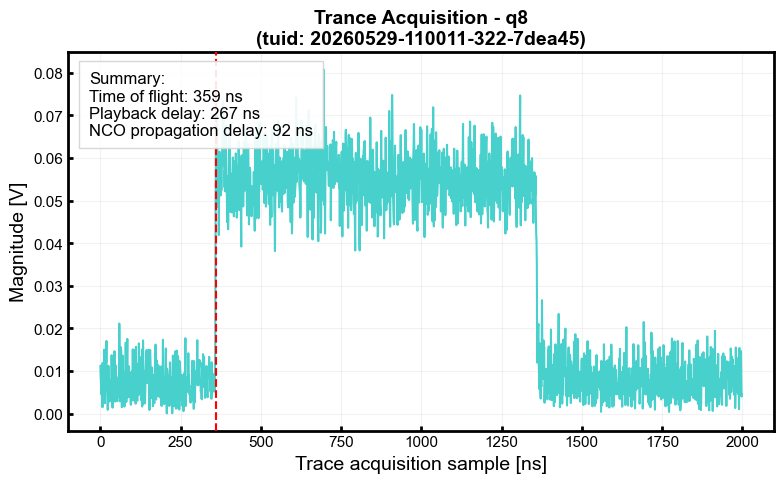

[q3] Acquisition delay directly set to: 3.590e-07 s (Broadcast from q8)
[q4] Acquisition delay directly set to: 3.590e-07 s (Broadcast from q8)
[q5] Acquisition delay directly set to: 3.590e-07 s (Broadcast from q8)
[q6] Acquisition delay directly set to: 3.590e-07 s (Broadcast from q8)
[q7A] Acquisition delay directly set to: 3.590e-07 s (Broadcast from q8)
[q8] Acquisition delay directly set to: 3.590e-07 s (Broadcast from q8)

--- Updating Readout NCO Delays on cluster_B, Module 6 ---
  -> seq0: NCO prop delay set to 92.0 ns
  -> seq1: NCO prop delay set to 92.0 ns
  -> seq2: NCO prop delay set to 92.0 ns
  -> seq3: NCO prop delay set to 92.0 ns
  -> seq4: NCO prop delay set to 92.0 ns
  -> seq5: NCO prop delay set to 92.0 ns
  -> seq6: NCO prop delay set to 92.0 ns
  -> seq7: NCO prop delay set to 92.0 ns


In [13]:
# set_attenuation(hw_agent, all_qubits, 'ro', 20)
# set_input_attenuation(hw_agent, all_qubits, 30)

# Execute TOF 
tof = TimeOfFlight(qubit, module_number=6)

tof.execute(
    frequency_detuning=50e6, 
    pulse_duration=1e-6, 
    pulse_amp=0.15, 
    acquisition_duration=2e-6, 
    repetitions=100
)

tof.analyze(acquisition_delay=0, playback_delay=267e-9)
tof.plot_analysis()
tof.post_run(qubits_to_update=all_qubits)

In [14]:
# Plot Time of Flight Pulse Diagram
tof = TimeOfFlight(qubit, module_number=6)
tof.execute(
    frequency_detuning=50e6, 
    pulse_duration=1e-6, 
    pulse_amp=0.7, 
    acquisition_duration=2e-6, 
    repetitions=1
)
compiled_schedule = tof.compile()
compiled_schedule.plot_pulse_diagram(plot_backend='plotly')

/Users/renychang/Downloads/flux-tunable-transmons-with-flux-tunable-couplers-share_with_AS_for_training/docs/applications/superconducting/cal00_time_of_flight.py:38: FutureWarning: clock_freq_new is deprecated as an argument to SetClockFrequency and will be removed in qblox-scheduler >= 2.0; use frequency instead.
  tof_sched.add(SetClockFrequency(


In [ ]:
compiled_schedule.compiled_instructions

# Resonator spectroscopy measurements

In [ ]:
res_spec_multi = MultiplexedResonatorSpectroscopy(all_qubits)

# 2. Execute the schedule on the hardware
res_spec_multi.execute(
    frequency_width=15e6,      # 20 MHz sweep width
    frequency_npoints=100,     # 100 frequency points
    repetitions=20,          # Number of averages
    ro_amp=0.02,
)

# 3. Process the data
# We can use the magnitude fit since this is a basic sweep
res_spec_multi.analyze()

# 4. Visualize the results
res_spec_multi.plot_analysis()

In [ ]:
res_spec_multi.post_run()

In [ ]:
# Plot Narrowband Resonator Spectroscopy Pulse Diagram
rs_multi_dummy = MultiplexedResonatorSpectroscopy(qubit)
rs_multi_dummy.execute(frequency_width=10e6, frequency_npoints=5, repetitions=1)
compiled_schedule = rs_multi_dummy.compile()
compiled_schedule.plot_pulse_diagram(plot_backend='plotly')

# Resonator punchout

In [ ]:
rs_punch = MultiplexedResonatorPunchout(qubit)
rs_punch.execute(
    frequency_width=10e6, 
    frequency_npoints=200, 
    att_start=10, 
    att_stop=30, 
    att_step=2, 
    repetitions=100,
    ro_amp=0.2
)

rs_punch.analyze()
rs_punch.plot_analysis()

# Overwrite hardware config based on visuals
# rs_punch.post_run(readout_attenuation=16)

In [ ]:
# Plot Resonator Punchout (Att) Pulse Diagram
rs_punch_dummy = MultiplexedResonatorPunchout(qubit)
rs_punch_dummy.execute(frequency_width=10e6, frequency_npoints=2, att_start=10, att_stop=12, att_step=2, repetitions=1)
compiled_schedule = rs_punch_dummy.compile()
compiled_schedule.plot_pulse_diagram(plot_backend='plotly')

In [ ]:
rs_punch_amp = MultiplexedResonatorPunchoutAmp(qubit)
rs_punch_amp.execute(
    frequency_width=10e6, 
    frequency_npoints=100, 
    amp_start=0.001, 
    amp_stop=0.4, 
    amp_nsteps=15, 
    repetitions=100,
    ro_att= 20
)

rs_punch_amp.analyze()
rs_punch_amp.plot_analysis()

In [ ]:
# Overwrite hardware config based on visuals
rs_punch_amp.post_run({"q3": 0.05, "q4": 0.05, "q4": 0.05})

In [ ]:
# Plot Resonator Punchout (Amp) Pulse Diagram
rs_punch_amp_dummy = MultiplexedResonatorPunchoutAmp(qubits)
rs_punch_amp_dummy.execute(frequency_width=10e6, frequency_npoints=2, amp_start=0.1, amp_stop=0.2, amp_nsteps=2, repetitions=1)
compiled_schedule = rs_punch_amp_dummy.compile()
compiled_schedule.plot_pulse_diagram(plot_backend='plotly')

# Resonator flux spectroscopy

In [ ]:
# flux_spec_multi = MultiplexedResonatorFluxSpectroscopy(qubit)
flux_spec_multi = MultiplexedResonatorFluxSpectroscopy(all_qubits)

flux_spec_multi.execute(
    frequency_width=10e6,       
    frequency_npoints=150,      
    flux_start=-0.3,          
    flux_stop=0.3,            
    flux_step=0.025,           
    repetitions=100 
)

flux_spec_multi.analyze()
flux_spec_multi.plot_analysis()

In [ ]:
flux_spec_multi.post_run()

In [ ]:
# read and update qubit parameters from device config
q3 = hw_agent.quantum_device.get_element("q3")
q4 = hw_agent.quantum_device.get_element("q4")
q5 = hw_agent.quantum_device.get_element("q5")

q6 = hw_agent.quantum_device.get_element("q6")
q7A = hw_agent.quantum_device.get_element("q7A")
q8 = hw_agent.quantum_device.get_element("q8")

# Divide qubits per multiplexed readout line
qubits_ro_3_5 = [q3, q4, q5]
qubits_ro_6_8 = [q6, q7A, q8]
all_qubits = [q3, q4, q5,q6, q7A, q8]
# qubit = [q3]
# qubit = [q8]
qubit = [q7A]

In [ ]:
# Plot Flux Spectroscopy Pulse Diagram
flux_spec_dummy = MultiplexedResonatorFluxSpectroscopy(all_qubits)
flux_spec_dummy.execute(frequency_width=5e6, frequency_npoints=2, flux_start=-0.5, flux_stop=0.5, flux_step=0.1, repetitions=1)
compiled_schedule = flux_spec_dummy.compile()
compiled_schedule.plot_pulse_diagram(plot_backend='plotly')

# Compensated resonator flux spectroscopy

In [ ]:
# 1. Define your routing dynamically
# Victims: Only measure the readout lines of actual qubits
victims = [q3]  # e.g., [q3, q4, q5, q6, q7, q8]

# Aggressors: Sweep the flux lines of everything on the chip
aggressors = [c34, c45, q3, q4, q5]  # e.g., qubits + [c34, c45, c56, c67, c78]

# 2. Initialize the Experiment
xtalk_cal = UnitCellCrosstalkCalibration(victims=victims, aggressors=aggressors)

# 3. Execute the multiplexed sweep
# Keep the flux sweep narrow to stay in the linear regime of the victim's sensitivity
xtalk_cal.execute(
    flux_start=0, 
    flux_stop=0.2, 
    flux_npoints=10,
    freq_width=10e6,  
    freq_npoints=100, 
    repetitions=100
)

# Run the math
xtalk_cal.analyze()

# Only plot the single unified matrix!
xtalk_cal.plot_crosstalk_matrix()

In [ ]:

# (Optional) If the matrix shows a weird value for q3 vs q4, you can inspect just that one:
xtalk_cal.plot_analysis(["q3_from_q3"])

In [ ]:
xtalk_cal.post_run()

In [ ]:
q3.flux_params.crosstalk_vector

In [ ]:
# =============================================================================
# EXAMPLE: Compensated Multiplexed Resonator Flux Spectroscopy
# =============================================================================

# 1. Define the Targets and the Compensation Environment
# The qubits we want to actively sweep and measure (e.g., multiplexed on line B18)
target_qubits = qubits_ro_3_5  # [q3, q4, q5]

# The complete list of elements that exist in the physical crosstalk environment.
# The matrix will ensure none of these elements drift while the targets are swept.
compensation_elements = all_elements  # qubits + couplers

# 2. Initialize the Experiment
comp_flux_spec = CompensatedResonatorFluxSpectroscopy(
    qubits=target_qubits, 
    all_unit_cell_elements=compensation_elements
)

# 3. Execute the Schedule
print("Executing Compensated Resonator Flux Spectroscopy...")
comp_flux_spec.execute(
    frequency_width=10e6,      # 10 MHz sweep around the expected resonator center
    frequency_npoints=1,      # 51 frequency points
    flux_start=-0.05,          # Logical flux start (-50 mV)
    flux_stop=0.05,            # Logical flux stop (+50 mV)
    flux_step=0.01,           # 2 mV steps
    repetitions=1           # Number of averages per point
)

# 4. Analyze and Plot
# (Inherited from the base MultiplexedResonatorFluxSpectroscopy class)
comp_flux_spec.analyze()
comp_flux_spec.plot_analysis()

# Qubit spectroscopy

In [ ]:
q3.clock_freqs.f01 = 3.873e9
q4.clock_freqs.f01 = 3.9483e9
q5.clock_freqs.f01 = 3.968e9

q6.clock_freqs.f01 = 4.205e9
q7A.clock_freqs.f01 = 3.861e9
q8.clock_freqs.f01 = 3.79e9

In [ ]:
target_att = {
    "q3": 20,
    "q4": 20,
    "q5": 20,
    "q6": 20,
    "q8": 24,
    "q7A": 20,
}

target_voltage = {
    "q3": 0.01,
    "q4": 0.01,
    "q5": 0.01,
    "q6": 0.01,
    "q8": 0.01,
    "q7A": 0.03,
}

# 1. Initialize the experiment with your hardware qubits
# qubit_spec_multi = MultiplexedQubitSpectroscopy(qubit)
qubit_spec_multi = MultiplexedQubitSpectroscopy(all_qubits)

# 2. Execute the schedule on the hardware
qubit_spec_multi.execute(
    f01_width=50e6, 
    f01_npoints=200, 
    repetitions=200,
    voltage_offset=target_voltage, 
    drive_att=target_att           
)

# 3. Process & visualize
qubit_spec_multi.analyze()
qubit_spec_multi.plot_analysis()  
qubit_spec_multi.plot_iq()  

In [ ]:
qubit_spec_multi.post_run()

In [ ]:
# Plot Qubit Spectroscopy Pulse Diagram
qubit_spec_dummy = MultiplexedQubitSpectroscopy(qubits)
qubit_spec_dummy.execute(f01_width=200e6, f01_npoints=5, voltage_offset=0.03, repetitions=1)
compiled_schedule = qubit_spec_dummy.compile()
compiled_schedule.plot_pulse_diagram(plot_backend='plotly')

# CW Qubit Flux Spectroscopy

In [ ]:
# Create a dictionary mapping the victim qubit to the physical coupler 
# you want to sweep. (e.g. sweep c34's flux while probing q3's frequency)
aggressor_mapping = {
    "q3": q3
}

cw_flux_spec = MultiplexedCWFluxQubitSpectroscopy(qubits=[q3])

# Execute with the mapping applied
cw_flux_spec.execute(
    cw_amp=0.01,                   # 200 mV continuous wave drive
    aggressor_mapping=aggressor_mapping, 
    flux_span=0.06,              
    flux_npoints=11,
    freq_shift_start=-80e6, 
    freq_shift_stop=80e6,
    freq_npoints=100,
    repetitions=100
)

cw_flux_spec.analyze()
cw_flux_spec.plot_analysis()

# Rabi

In [ ]:
# Define dictionaries for specific qubits
target_att = {
    # "q3": 18,
    "q8": 24,
    # "q7B": 20,
}

target_duration={
        # "q3": 100e-9,
        "q8": 100e-9,
        # "q7B": 100e-9,
    }

power_rabi_multi = MultiplexedPowerRabi(qubit)
power_rabi_multi.execute(
    amp_start=0, 
    amp_stop=0.9, 
    amp_npoints=50, 
    repetitions=400,
    drive_att=target_att,         
    drive_duration=target_duration 
)

power_rabi_multi.analyze()
power_rabi_multi.plot_analysis()
# power_rabi_multi.plot_iq()



In [ ]:
power_rabi_multi.post_run()

In [ ]:
# Plot Power Rabi Pulse Diagram
power_rabi_dummy = MultiplexedPowerRabi(qubit)
power_rabi_dummy.execute(amp_start=0, amp_stop=0.5, amp_npoints=2, repetitions=1)
compiled_schedule = power_rabi_dummy.compile()
compiled_schedule.plot_pulse_diagram(plot_backend='plotly')

# Flux Qubit Spectroscopy

In [ ]:
pulsed_flux_spec = MultiplexedPulsedFluxQubitSpectroscopy(qubit)

# Sweep fluxaround the sweet spot, and sweep freq
pulsed_flux_spec.execute(
    flux_span=0.06,
    flux_npoints=11, 
    freq_shift_start=-80e6, 
    freq_shift_stop=80e6, 
    freq_npoints=100, 
    repetitions=100
)

pulsed_flux_spec.analyze()
pulsed_flux_spec.plot_analysis()

In [ ]:
pulsed_flux_spec.post_run()

In [ ]:
pulsed_flux_spec_dummy = MultiplexedPulsedFluxQubitSpectroscopy(qubits_ro_3_5)

# Sweep fluxaround the sweet spot, and sweep freq
pulsed_flux_spec_dummy.execute(
    flux_span=0.06,
    flux_npoints=1, 
    freq_shift_start=-80e6, 
    freq_shift_stop=80e6, 
    freq_npoints=5, 
    repetitions=1
)
compiled_schedule = pulsed_flux_spec_dummy.compile()
compiled_schedule.plot_pulse_diagram(plot_backend='plotly')

# $T_1$

In [ ]:
voltages = np.linspace(0,1,5)
for v in voltages:

    print("--- Starting Safe Flux Ramp for Couplers ---")

    # 1. Map each coupler's name to its exact hardware DC offset parameter
    # (Derived directly from your JSON connectivity graph)
    coupler_hardware_map = {
        "c78": clusters["cluster_A"].module6.out1_offset,
    }

    # 2. Iterate through all couplers to update software and hardware
    for coupler in all_couplers:
        
        target_voltage = 0  # Volts
        
        # Update the software quantum device element
        coupler.flux_params.sweet_spot = v
    
        
        # Apply safety limits for the step-wise ramp
        hw_offset.inter_delay = 100e-9  # Delay time between consecutive set operations (100 ns)
        hw_offset.step = 0.3e-3         # Stepsize in V during set operation (0.3 mV)
        
        # Initialize the step generator by getting the current value, then ramp
        current_v = hw_offset.get()

        hw_offset.set(v)

        t1_multi = MultiplexedT1(qubit)
        t1_multi.execute(
            tau_start=1e-6, 
            tau_stop=100e-6, 
            tau_step=2e-6, 
            repetitions=200,
        )

        t1_multi.analyze()
        # t1_multi.plot_iq()
        t1_multi.plot_analysis()

        print("--- All couplers safely parked at their sweet spots! ---")

In [ ]:
t1_multi = MultiplexedT1(qubit)
t1_multi.execute(
    tau_start=1e-6, 
    tau_stop=150e-6, 
    tau_step=2e-6, 
    repetitions=500,
)

t1_multi.analyze()
# t1_multi.plot_iq()
t1_multi.plot_analysis()

In [ ]:
# Plot T1 Pulse Diagram
t1_dummy = MultiplexedT1(qubit)
t1_dummy.execute(tau_start=1e-6, tau_stop=3e-6, tau_step=2e-6, repetitions=1)
compiled_schedule = t1_dummy.compile()
compiled_schedule.plot_pulse_diagram(plot_backend='plotly')

# Ramsey

In [ ]:
ramsey_multi = MultiplexedRamsey(qubit)
ramsey_multi.execute(
    tau_start=4e-9, 
    tau_stop=1e-6,
    tau_step=8e-9, 
    frequency_detuning=10e6,
    repetitions=500
)

ramsey_multi.analyze()
ramsey_multi.plot_iq()
ramsey_multi.plot_analysis()



In [ ]:
# ramsey_multi.post_run(sign_overrides={"q8": -1}, qubits_to_update=["q8"])
ramsey_multi.post_run()

In [ ]:
ramsey_multi = MultiplexedRamsey(qubit)
ramsey_multi.execute(
    tau_start=1e-6, 
    tau_stop=33e-6,
    tau_step=300e-9, 
    frequency_detuning=0.5e6,
    repetitions=500
)

ramsey_multi.analyze()
# ramsey_multi.plot_iq()
ramsey_multi.plot_analysis()



In [ ]:
# Plot Ramsey Pulse Diagram
ramsey_dummy = MultiplexedRamsey(qubits)
ramsey_dummy.execute(tau_start=1e-6, tau_stop=3e-6, tau_step=2e-6, frequency_detuning=5e6, repetitions=1)
compiled_schedule = ramsey_dummy.compile()
compiled_schedule.plot_pulse_diagram(plot_backend='plotly')

# Error amplification on pi pulse

In [ ]:
# 1. Initialize the experiment with your list of active qubits
# (Assuming 'qubits' is already defined in your notebook, e.g., qubits = [q0, q1, q2, q3])
pi_pulse_error_amplification = MultiplexedPiPulseErrorAmplification(qubit)

# 2. Execute the sequence
# - amp_rel_span = 0.1: We sweep +/- 10% around the currently calibrated amp180
# - n_values: We strictly use ODD numbers so the pulse sequence always 
#             aims to leave the qubit on the equator of the Bloch sphere
#             (where measurement sensitivity to angle errors is perfectly maximized).
pi_pulse_error_amplification.execute(
    amp_rel_span=0.2, 
    amp_npoints=31, 
    n_values=[1,3,5, 7, 9, 11], 
    repetitions=200
)

# 3. Fit the 2D surface to calculate the amplitude scale factors
pi_pulse_error_amplification.analyze()

# 4. Plot the heatmap and the classic "bowtie" intersections
pi_pulse_error_amplification.plot_analysis()



In [ ]:
# 5. Update the device configuration
# You can leave it empty to update all successful fits: pi_pulse_error_amplification.post_run()
# Or you can selectively update just the ones that look clean in the plots:
pi_pulse_error_amplification.post_run()

# Error amplification on pi/2 pulse

In [ ]:
# 1. Initialize the experiment with your active qubits
# (Assuming 'qubits' is already defined, e.g., qubits = [q0, q1, q2, q3])
pi_half_pulse_error_amplification = MultiplexedPiHalfPulseErrorAmplification([q3])

# 2. Execute the sequence
# - amp_rel_span = 0.1: Sweeps +/- 10% around the currently calibrated amp180
# - n_values: Number of pi/2 pulse PAIRS. [1, 2, 3, 4, 5, 6, 7] maps to [2, 4, 6, 8, 10, 12, 14] physical pulses.
pi_half_pulse_error_amplification.execute(
    amp_rel_span=0.05, 
    amp_npoints=41, 
    n_values=[1,2,3, 4, 5, 6, 7, 8], 
    repetitions=400
)

# 3. Fit the 2D surface to calculate the amplitude scale factors
pi_half_pulse_error_amplification.analyze()

# 4. Plot the heatmap and the "bowtie" intersections
pi_half_pulse_error_amplification.plot_analysis()



In [ ]:
# 5. Safely update the device configuration!
# Because X90 dynamically divides amp180 by 2 in Qblox, this seamlessly updates 
# your global amp180 baseline to make your pi/2 pulses mathematically perfect.

pi_half_pulse_error_amplification.post_run()

In [ ]:
# read and update qubit parameters from device config
q3 = hw_agent.quantum_device.get_element("q3")

# DRAG Calibration

In [ ]:
def generate_drag(t, amplitude, beta, duration, nr_sigma=4):
    """Calculates the I and Q components of a DRAG pulse."""
    mu = t[0] + duration / 2
    sigma = duration / (2 * nr_sigma)
    
    # I-component (Gaussian)
    gauss_env = amplitude * np.exp(-(0.5 * ((t - mu) ** 2) / sigma**2))
    
    # Q-component (Derivative)
    deriv_gauss_env = -beta * (t - mu) / sigma**2 * gauss_env
    
    return gauss_env, deriv_gauss_env

# 1. Define pulse parameters
duration = q3.rxy.duration  # 40 ns pulse
t = np.linspace(0, duration, 1000)
amplitude = q3.rxy.amp180

# 2. Generate waveforms for positive and negative beta
I_base, Q_pos = generate_drag(t, amplitude, beta=1e-8, duration=duration)
_     , Q_neg = generate_drag(t, amplitude, beta=-1e-8, duration=duration)

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# Plot Beta = +1e-8
ax1.plot(t * 1e9, I_base, 'k--', lw=2, label='I (Real) - Gaussian')
ax1.plot(t * 1e9, Q_pos, 'b-', lw=2, label=r'Q (Imag) - DRAG ($\beta = +10^{-8}$)')
ax1.set_title(r"DRAG Pulse ($\beta > 0$)")
ax1.set_xlabel("Time (ns)")
ax1.set_ylabel("Amplitude (a.u.)")
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='lower center')

# Plot Beta = -1e-8
ax2.plot(t * 1e9, I_base, 'k--', lw=2, label='I (Real) - Gaussian')
ax2.plot(t * 1e9, Q_neg, 'r-', lw=2, label=r'Q (Imag) - DRAG ($\beta = -10^{-8}$)')
ax2.set_title(r"DRAG Pulse ($\beta < 0$)")
ax2.set_xlabel("Time (ns)")
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='lower center')

plt.tight_layout()
plt.show()

In [ ]:
# 1. Initialize the experiment
drag_cal = MultiplexedDRAGCalibration([q3])

# 2. Execute the sweep
drag_cal.execute(
    beta_start=-5e-9, 
    beta_stop=5e-9, 
    beta_npoints=41, 
    pulse_repetitions=1,  # Try 3 or 5 if the lines are too flat!
    repetitions=500
)

# 3. Analyze and plot
drag_cal.analyze()
drag_cal.plot_analysis()



In [ ]:
# 4. Save the optimal beta back to the device config
drag_cal.post_run()

# T2 as a function of flux

In [ ]:
# Initialize the experiment
ramsey_flux = MultiplexedRamseyVsFlux([q3])

# Execute the 2D Sweep
ramsey_flux.execute(
    tau_start=1e-6, 
    tau_stop=20e-6,
    tau_step=180e-9,  
    frequency_detuning=0.1e6,   #  artificial detuning
    flux_span=0.015,           # Sweeps +/- around current sweet spot
    flux_npoints=10,          # flux slices
    repetitions=200           # Shots per point
)

# Fit the S21 traces to find T2*, then fit the T2* array to find the peak
ramsey_flux.analyze()

# Plot the 2D Heatmap and the 1D Parabola
ramsey_flux.plot_analysis()

# Automatically update the qubits with their new maximized sweet spot
# ramsey_flux.post_run()

# Echo

In [ ]:
echo_multi = MultiplexedEcho(qubit)
echo_multi.execute(
    tau_start=1e-6, 
    tau_stop=50e-6, 
    tau_step=1e-6, 
    frequency_detuning=0, 
    repetitions=1000
)

echo_multi.analyze()
# echo_multi.plot_iq()
echo_multi.plot_analysis()

In [ ]:
echo_multi.plot_iq()

In [ ]:
# Plot Echo Pulse Diagram
echo_dummy = MultiplexedEcho(qubits)
echo_dummy.execute(tau_start=1e-6, tau_stop=3e-6, tau_step=2e-6, frequency_detuning=0.5e6, repetitions=1)
compiled_schedule = echo_dummy.compile()
compiled_schedule.plot_pulse_diagram(plot_backend='plotly')

# Dispersive shift

In [ ]:
ds_multi = MultiplexedDispersiveShift(qubit)

ds_multi.execute(
    frequency_width=10e6,  
    frequency_npoints=100, 
    repetitions=400
)

ds_multi.analyze()
ds_multi.plot_analysis()

In [ ]:
ds_multi.post_run()

In [ ]:
# Plot Dispersive Shift Pulse Diagram
ds_dummy = MultiplexedDispersiveShift(qubits)
ds_dummy.execute(frequency_width=5e6, frequency_npoints=2, repetitions=1)
compiled_schedule = ds_dummy.compile()
compiled_schedule.plot_pulse_diagram(plot_backend='plotly')

# Single shot readout

Running Double-Gaussian SSRO analysis for q8...
[q8] Assignment Fidelity: 87.00%


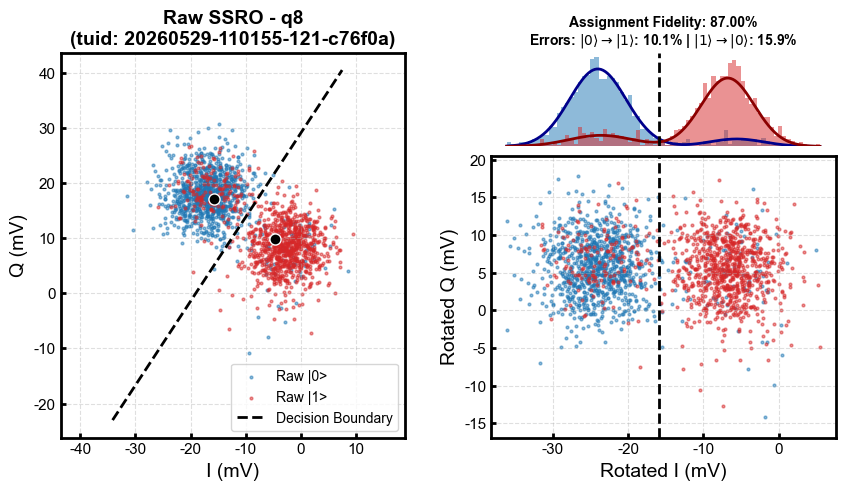

In [15]:
# -------------------------------
# OPTION A: Standard single SSRO
# -------------------------------
ssro = MultiplexedSSRO(qubit)
ssro.execute(repetitions=1000)
ssro.analyze()
ssro.plot_analysis()

In [16]:
ssro.post_run()

[q8] acq_rotation updated: 36.32° → 33.26°
       acq_threshold updated: -1.665770e-02 V → -1.594206e-02 V


In [ ]:
# Plot SSRO Pulse Diagram
ssro_dummy = MultiplexedSSRO(qubits)
ssro_dummy.execute(repetitions=2) # 2 Repetitions to see both |0> and |1> logic
compiled_schedule = ssro_dummy.compile()
compiled_schedule.plot_pulse_diagram(plot_backend='plotly')

In [ ]:
# -------------------------------
# OPTION B: Optimization Sweep
# -------------------------------
readout_amplitudes = np.linspace(0.001, 0.05, 5)

opt_sweep = MultiplexedReadoutAmplitudeOptimization([q3])
opt_sweep.execute(readout_amplitudes=readout_amplitudes, repetitions=500)
opt_sweep.plot_analysis()



In [ ]:
# Manually save optimal settings looking at the plot output
opt_sweep.post_run({
    "q3": 0.02
})

In [ ]:
# Initialize
freq_opt = MultiplexedReadoutFrequencyOptimization(qubits)

# Sweep from -3 MHz to +3 MHz in 21 steps (roughly 300 kHz steps)
detunings = np.linspace(-0.4e6, 0.4e6, 9)

# Execute the sweep
freq_opt.execute(freq_detunings=detunings, repetitions=500)

# View the fidelity peaks
freq_opt.plot_analysis()

# # Supply the optimal detunings (in MHz) that you read off the plot axis
# freq_opt.post_run({
#     "q0": -0.3,  # Shifts q0 readout down by 300 kHz
#     "q1": +1.2,  # Shifts q1 readout up by 1.2 MHz
# })

# AllXY

/Users/renychang/Downloads/flux-tunable-transmons-with-flux-tunable-couplers-share_with_AS_for_training/.venv/lib/python3.11/site-packages/qblox_scheduler/operations/acquisition_library.py:1559: FutureWarning: Using the `AVERAGE` bin mode deprecated. Use the `AVERAGE_APPEND` instead. 
  warnings.warn(


[q8] AllXY Analysis Complete.


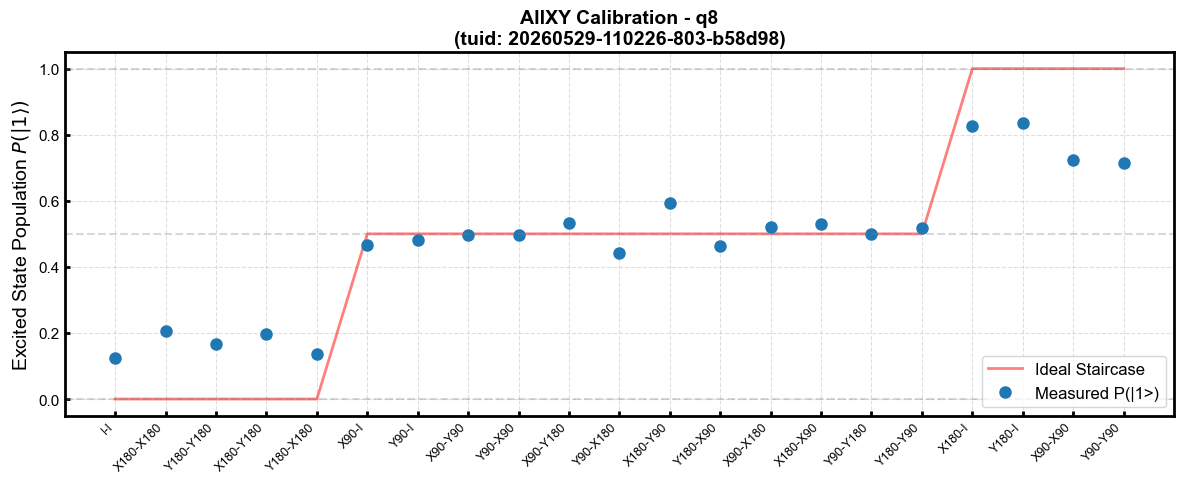

In [17]:
allxy_exp = MultiplexedAllXY(qubit)

# Execute
allxy_exp.execute(repetitions=1000)

allxy_exp.analyze()
allxy_exp.plot_analysis()


# Active Reset Verification

In [ ]:
active_reset_multi = MultiplexedActiveReset([q3])

# Execute 1000 repetitions
active_reset_multi.execute(repetitions=1000)

# Extract and Plot the IQ blobs
active_reset_multi.analyze()
active_reset_multi.plot_analysis()



In [ ]:
# Plot Active Reset Pulse Diagram
ar_dummy = MultiplexedActiveReset([q3])
ar_dummy.execute(repetitions=1)
compiled_schedule = ar_dummy.compile()
compiled_schedule.plot_pulse_diagram(plot_backend='plotly')

# Readout Amplitude Calibration (Stark Shift)

In [ ]:
ro_amp_cal = MultiplexedReadoutAmplitudeCalibration([q3])

# Execute the sweep (Takes a moment due to the 2D nature)
ro_amp_cal.execute(
    amp_stop=0.025, 
    amp_npoints=10, 
    freq_shift_start=-80e6, 
    freq_shift_stop=80e6,
    freq_npoints=50,
    repetitions=100
)

# Analyze targeting a given Stark shift
ro_amp_cal.analyze(target_shift_hz=-10e6,fit_amp_limit=0.5)
ro_amp_cal.plot_analysis()

In [ ]:
# Save the new Readout Amplitude!
ro_amp_cal.post_run()

# Dual Drive Ramsey

In [ ]:
# 2. Define your dual-drive pairs
# The first element is the Primary (Readout/Flux/Drive A). 
# The second element is the Secondary (Drive B).
qubit_pairs = [(q7A, q7B)]

# 3. Initialize the Experiment
dual_ramsey = DualDriveRamsey(qubit_pairs=qubit_pairs)

# 4. Execute the sequence on the hardware
# We apply a 1 MHz artificial detuning to create clean Ramsey fringes
dual_ramsey.execute(
    tau_start=4e-9,         
    tau_stop=1e-6,         
    tau_step=4e-9,        
    frequency_detuning=10e6, 
    repetitions=500        # Averages per point
)

# 5. Extract T2* and the true detuning error
dual_ramsey.analyze()

# 6. Visualize the data
dual_ramsey.plot_analysis()
dual_ramsey.plot_iq()

# 7. Push the corrected frequency to the Qblox Quantum Device
# This will safely update the f01 of BOTH q7A and q7B simultaneously!
# dual_ramsey.post_run()

In [ ]:
qubit_pairs = [(q7A, q7B)]
# 3. Initialize the Experiment
dual_ramsey_dummy = DualDriveRamsey(qubit_pairs=qubit_pairs)

# 4. Execute the sequence on the hardware
# We apply a 1 MHz artificial detuning to create clean Ramsey fringes
dual_ramsey_dummy.execute(
    tau_start=4e-9,         
    tau_stop=1e-6,         
    tau_step=600e-9,        
    frequency_detuning=10e6, 
    repetitions=1        # Averages per point
)
compiled_schedule = dual_ramsey_dummy.compile()
compiled_schedule.plot_pulse_diagram(plot_backend='plotly')

# TWPA Optimization

In [ ]:
#####
# MULTIPLEXED TWPA Pump Freq. and Power Optimization Sweep
##### 

# -------------------------------------------------------------------------
# 1. Sweep Parameters & Initialization
# -------------------------------------------------------------------------
freq_start = 8.0e9
freq_stop = 8.5e9
freq_points = 4  

power_start = 0.1
power_stop = 0.4
power_points = 4 

ssro_repetitions = 500 

pump_frequencies = np.linspace(freq_start, freq_stop, freq_points)
pump_powers = np.linspace(power_start, power_stop, power_points)

# Initialize dictionaries to hold individual fidelities, and a matrix for the mean
fidelities_dict = {q.name: np.full((power_points, freq_points), np.nan) for q in qubits}
mean_fidelities = np.full((power_points, freq_points), np.nan)

# -------------------------------------------------------------------------
# 2. Initial Hardware Setup
# -------------------------------------------------------------------------
print("Configuring TWPA pump sequencer...")
cluster['cluster'].module8.disconnect_outputs()
cluster['cluster'].module8.sequencer5.connect_out1('IQ')

cluster['cluster'].module8.sequencer5.marker_ovr_en(True)
cluster['cluster'].module8.sequencer5.marker_ovr_value(2)
cluster['cluster'].module8.sequencer5.nco_freq(0)

# -------------------------------------------------------------------------
# 3. Figure Setup for Subplots
# -------------------------------------------------------------------------
num_qubits = len(qubits)
cols = 2
rows = math.ceil(num_qubits / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))
if num_qubits > 1:
    axes = axes.flatten()
else:
    axes = [axes]

# Hide any unused subplots (e.g., if you have 3 qubits in a 2x2 grid)
for i in range(num_qubits, len(axes)):
    fig.delaxes(axes[i])

fig.suptitle("TWPA Optimization: Individual Readout Fidelities", fontweight='bold', fontsize=16)

# -------------------------------------------------------------------------
# 4. Execution Loop with Live Plotting
# -------------------------------------------------------------------------
total_points = freq_points * power_points
current_point = 1

for j, freq in enumerate(pump_frequencies):
    cluster['cluster'].module8.out1_lo_freq(freq)
    time.sleep(0.005) # LO settle
    
    for i, power in enumerate(pump_powers):
        cluster['cluster'].module8.out1_offset_path0(power)
        time.sleep(0.001) # Offset settle
        
        # Run Multiplexed SSRO
        ssro_exp = MultiplexedSSRO(qubits)
        ssro_exp.execute(repetitions=ssro_repetitions)
        ssro_exp.analyze(silent=True)
        
        # Extract individual fidelities and compute the mean
        current_fids = []
        fid_strings = []
        for q in qubits:
            if q.name in ssro_exp.analyses:
                fid = ssro_exp.analyses[q.name]['fidelity']
            else:
                fid = np.nan 
                
            fidelities_dict[q.name][i, j] = fid
            current_fids.append(fid)
            fid_strings.append(f"{q.name}: {fid*100:.1f}%" if not np.isnan(fid) else f"{q.name}: N/A")
            
        current_mean_fid = np.nanmean(current_fids)
        mean_fidelities[i, j] = current_mean_fid
        
        # --- LIVE PLOT REFRESH ---
        clear_output(wait=True)
        
        for idx, q in enumerate(qubits):
            ax = axes[idx]
            ax.clear()
            
            mesh = ax.pcolormesh(
                pump_frequencies / 1e9, 
                pump_powers, 
                fidelities_dict[q.name] * 100, 
                shading='auto', 
                cmap='RdYlGn',
                vmin=60, 
                vmax=100
            )
            
            ax.set_title(f"{q.name}", fontweight='bold')
            ax.set_xlabel("Pump Frequency (GHz)")
            ax.set_ylabel("Pump Amplitude (V)")
            
            # Only add the colorbar the very first time so it doesn't duplicate
            if current_point == 1:
                fig.colorbar(mesh, ax=ax, label="Fidelity (%)")
        
        fig.tight_layout()
        display(fig)
        
        # Print summary
        print(f"[{current_point}/{total_points}] Freq: {freq/1e9:.3f} GHz | Power: {power:.3f}")
        print(f"  -> Mean: {current_mean_fid*100:.2f}% | " + " | ".join(fid_strings))
        
        current_point += 1

# -------------------------------------------------------------------------
# 5. Cleanup
# -------------------------------------------------------------------------
cluster['cluster'].module8.out1_offset_path0(0.0)
cluster['cluster'].module8.sequencer5.marker_ovr_value(0)
plt.close(fig) 
print("\nSweep complete. TWPA pump turned off.")

# -------------------------------------------------------------------------
# 6. Extract and Report the Optimal Operating Points
# -------------------------------------------------------------------------
print("\n" + "=" * 60)
print("🏆 OPTIMAL TWPA CONFIGURATION FOUND")
print("=" * 60)

# Global Optimum (Maximizes Mean Fidelity)
best_global_idx = np.unravel_index(np.nanargmax(mean_fidelities), mean_fidelities.shape)
best_freq = pump_frequencies[best_global_idx[1]]
best_power = pump_powers[best_global_idx[0]]

print(f"[GLOBAL OPTIMUM - Maximizing Mean Fidelity]")
print(f"  -> Frequency : {best_freq / 1e9:.4f} GHz")
print(f"  -> Power     : {best_power:.4f} V")
print(f"  -> Mean Fid  : {mean_fidelities[best_global_idx] * 100:.2f}%")
print("-" * 60)

# Individual Best Points
print("Theoretical Best Point for Each Individual Qubit:")
for q in qubits:
    q_fids = fidelities_dict[q.name]
    best_q_idx = np.unravel_index(np.nanargmax(q_fids), q_fids.shape)
    q_best_freq = pump_frequencies[best_q_idx[1]]
    q_best_power = pump_powers[best_q_idx[0]]
    q_best_fid = q_fids[best_q_idx]
    
    # Also grab what this qubit's fidelity was AT the global optimum for comparison
    fid_at_global = q_fids[best_global_idx]
    
    print(f"  [{q.name}] Best: {q_best_freq/1e9:.4f} GHz, {q_best_power:.4f} V (Fid: {q_best_fid*100:.2f}%)")
    print(f"        (At Global Optimum: {fid_at_global*100:.2f}%)")
print("=" * 60)

In [ ]:
# Set the Local Oscillator (LO) to the desired TWPA pump frequency (8.5 GHz)
cluster['cluster'].module8.out1_lo_freq(8.2e9)

# Apply a DC offset to the I-path (path 0) of the mixer. 
# Because the NCO is at 0 Hz, this constant DC offset mixes with the LO 
# to generate a continuous microwave tone at exactly 8.5 GHz. 
# The value (0.2) dictates the amplitude/power of the pump tone.
cluster['cluster'].module8.out1_offset_path0(0.225)

# Single qubit Randomized Benchmarking

In [ ]:
import numpy as np
from dependencies.analysis_utils import RBAnalysis
from dependencies.randomized_benchmarking.utils import randomized_benchmarking_schedule
from xarray import open_dataset

from qblox_scheduler import HardwareAgent

In [ ]:
np.arange(0, 130, 40)

In [ ]:
# RB settings
lengths = np.arange(0, 130, 40)
seeds = np.random.randint(0, 2**31 - 1, size=10, dtype=np.int32)

repetitions = 1

In [ ]:
qubit = q0

In [ ]:
sched = randomized_benchmarking_schedule(
    qubit.name,
    lengths=lengths,
    repetitions=repetitions,
    seeds=seeds,
)

# Execute the experiment
rb_data = hw_agent.run(sched)

In [ ]:
rb_analysis = RBAnalysis(rb_data).run()
rb_analysis.display_figs_mpl()

# Cryoscope

In [ ]:
# -------------------------------------------------------------------------
# Cryoscope
# -------------------------------------------------------------------------

# -------------------------------------------------------------------------
# 1. Imports and Hardware Setup
# -------------------------------------------------------------------------
from cryoscope import CryoscopeExperiment

def main():
    # -------------------------------------------------------------------------
    # 2. Initialize the Experiment
    # -------------------------------------------------------------------------
    print("--- Initializing Cryoscope Measurement ---")
    
    # We pass the list of qubits we want to measure (e.g., just the first one)
    target_qubits = [qubits[0]]
    
    cryo_exp = CryoscopeExperiment(qubits=target_qubits)
    
    # Ensure the hardware agent is attached to the experiment so it can compile and run
    cryo_exp.hw_agent = hw_agent 

    # -------------------------------------------------------------------------
    # 3. Define Sweep Parameters & Execute
    # -------------------------------------------------------------------------
    flux_pulse_amplitude = 0.25  # Volts (The target amplitude of your square pulse)
    duration_start = 0.0         # Seconds
    duration_stop = 150e-9       # Seconds (150 ns is usually plenty to see the tail end)
    duration_points = 151        # Gives exactly 1 ns resolution
    shots = 2000                 # Averaging repetitions
    
    print(f"Sweeping flux pulse duration from {duration_start*1e9} to {duration_stop*1e9} ns...")
    
    cryo_exp.execute(
        amp=flux_pulse_amplitude,
        dur_start=duration_start,
        dur_stop=duration_stop,
        dur_npoints=duration_points,
        repetitions=shots
    )

    # -------------------------------------------------------------------------
    # 4. Analyze & Plot
    # -------------------------------------------------------------------------
    # The analyze method handles the PCA rotation, unwraps the phase, 
    # takes the derivative, and normalizes the step response.
    cryo_exp.analyze()

    # Generate the 3-panel plot (Raw, Phase, Step Response)
    cryo_exp.plot_analysis()

    # -------------------------------------------------------------------------
    # 5. Post-Run / Export
    # -------------------------------------------------------------------------
    # In a full pre-distortion pipeline, you would extract the step_response array 
    # here and feed it into an IIR/FIR filter generator.
    # cryo_exp.post_run()
    
    # Example of how you would grab the raw data for custom filter fitting later:
    # step_response_array = cryo_exp.analyses[target_qubits[0].name]['step_response']
    # time_axis = cryo_exp.analyses[target_qubits[0].name]['unique_dur']
    
    print("--- Cryoscope Measurement Complete ---")



In [ ]:
#2D Chevron 

# 2-Qubit Chevron - Phase Calibration

In [1]:
# -------------------------------------------------------------------------
# 1. Imports and Hardware Setup
# -------------------------------------------------------------------------

from coupled_qubits_chevron import ChevronAvoidedCrossing

def main():
    print("--- Initializing 2-Qubit Chevron Measurement ---")
    
    # -------------------------------------------------------------------------
    # 2. Assign Qubit and Coupler Roles
    # -------------------------------------------------------------------------
    # Select the specific qubits and coupler for this CZ gate calibration.
    # Adjust these indices to match the specific pair you are testing on the chip!
    q_control = qubits[0]
    q_target = qubits[1]
    flux_element = couplers[0] # The tunable coupler sitting between q0 and q1
    
    print(f"Control Qubit : {q_control.name}")
    print(f"Target Qubit  : {q_target.name}")
    print(f"Flux Element  : {flux_element.name}")

    # Instantiate the experiment
    chevron_exp = ChevronAvoidedCrossing(
        q_control=q_control, 
        q_target=q_target, 
        flux_element=flux_element, 
        hw_agent=hw_agent
    )

    # -------------------------------------------------------------------------
    # 3. Define Sweep Parameters & Execute
    # -------------------------------------------------------------------------
    # Amplitude sweep (Volts)
    amplitude_start = -0.5
    amplitude_stop = 0.5
    amplitude_points = 41  # 41 points gives nice resolution for the 2D plot

    # Duration sweep (Seconds)
    duration_start = 4e-9  
    duration_stop = 150e-9 
    
    # IMPORTANT: The Qblox sequencer grid operates in multiples of 1ns (or 4ns depending on the operation).
    # Keeping the step at 4ns ensures perfectly clean hardware loops.
    duration_step = 4e-9   

    shots = 1000  # Number of averaging repetitions per pixel on the heatmap

    print("\nStarting 2D Chevron Sweep...")
    print(f"Amplitudes : {amplitude_points} points from {amplitude_start} V to {amplitude_stop} V")
    print(f"Durations  : From {duration_start*1e9} ns to {duration_stop*1e9} ns (Step: {duration_step*1e9} ns)")
    
    # Execute the hardware sweep
    chevron_exp.execute(
        amp_start=amplitude_start,
        amp_stop=amplitude_stop,
        amp_npoints=amplitude_points,
        dur_start=duration_start,
        dur_stop=duration_stop,
        dur_step=duration_step,
        repetitions=shots
    )

    # -------------------------------------------------------------------------
    # 4. Analyze & Plot
    # -------------------------------------------------------------------------
    print("\nAnalyzing dataset...")
    # This locates the maximum variance (the avoided crossing) and fits the swap duration
    chevron_exp.analyze()

    print("Generating plots...")
    # This pops up the 2D Heatmap and the 1D slice of the damped sine wave fit
    chevron_exp.plot_analysis()

    # -------------------------------------------------------------------------
    # 5. Post-Run / Update Hardware Dictionary
    # -------------------------------------------------------------------------
    print("\nUpdating hardware parameters...")
    # This pushes the newly found optimal amplitude and duration back into the hardware agent
    chevron_exp.post_run()
    
    print("--- Chevron Calibration Complete ---")

if __name__ == "__main__":
    main()

ModuleNotFoundError: No module named 'coupled_qubits_chevron'